# <center>Class 16: Random Forest and Boosting
</center>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import os
# from pathlib import Path
import sys
from patsy import dmatrices
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error

### Get Data

In [2]:
path = os.path.join(os.pardir, 'data', 'airbnb_london_workfile_adj_book.csv') # this will produce a path with the right syntax for your operating system
path

'../data/airbnb_london_workfile_adj_book.csv'

In [3]:
# DATA IMPORT - FROM FILE
df = pd.read_csv(path)

In [4]:
df.head()

,f_property_type,f_room_type,f_room_type2,f_cancellation_policy,f_bed_type,f_neighbourhood_cleansed,usd_price_day,n_accommodates,n_bathrooms,n_review_scores_rating,...,flag_days_since,flag_review_scores_rating,flag_reviews_per_month,flag_n_number_of_reviews,ln_days_since,ln_days_since2,ln_days_since3,n_days_since2,n_days_since3,ln_review_scores_rating
0,Apartment,Private room,Private,flexible,Real Bed,Kingston upon Thames,23,1,1.0,100,...,0,0,0,0,4.532599,20.544458,93.119801,8464,778688,4.605170
1,Apartment,Private room,Private,moderate,Couch,Kingston upon Thames,50,2,1.0,91,...,0,0,0,0,6.510258,42.383464,275.927298,450241,302111711,4.510860
2,Apartment,Private room,Private,flexible,Real Bed,Kingston upon Thames,24,2,1.0,80,...,0,0,0,0,5.493061,30.173724,165.746120,58564,14172488,4.382027
3,House,Private room,Private,flexible,Real Bed,Kingston upon Thames,50,2,1.5,94,...,1,1,1,1,5.793014,33.559007,194.407782,106929,34965783,4.543295
4,House,Private room,Private,flexible,Real Bed,Kingston upon Thames,25,1,1.0,94,...,1,1,1,1,5.793014,33.559007,194.407782,106929,34965783,4.543295


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51646 entries, 0 to 51645
Data columns (total 92 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   f_property_type            51646 non-null  object 
 1   f_room_type                51646 non-null  object 
 2   f_room_type2               51646 non-null  object 
 3   f_cancellation_policy      51646 non-null  object 
 4   f_bed_type                 51646 non-null  object 
 5   f_neighbourhood_cleansed   51646 non-null  object 
 6   usd_price_day              51646 non-null  int64  
 7   n_accommodates             51646 non-null  int64  
 8   n_bathrooms                51646 non-null  float64
 9   n_review_scores_rating     51646 non-null  int64  
 10  n_number_of_reviews        51646 non-null  int64  
 11  n_guests_included          51646 non-null  int64  
 12  n_reviews_per_month        51646 non-null  float64
 13  n_extra_people             51646 non-null  int

In [6]:
df.isna().sum().sum()

0

### EDA

In [7]:
# We focus on normal apartments, n < 8
df = df[df.n_accommodates < 8]

In [8]:
df.shape

(49826, 92)

In [9]:
# copy a variable - purpose later, see at variable importance
df['n_accommodates_copy'] = df['n_accommodates']

***numerical variables***

In [10]:
# too long to display and read
df.describe().T

,count,mean,std,min,25%,50%,75%,max
usd_price_day,49826.0,8.898404e+01,7.051509e+01,8.000000,4.100000e+01,7.000000e+01,1.100000e+02,9.990000e+02
n_accommodates,49826.0,2.838759e+00,1.494748e+00,1.000000,2.000000e+00,2.000000e+00,4.000000e+00,7.000000e+00
n_bathrooms,49826.0,1.224260e+00,4.664481e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
n_review_scores_rating,49826.0,9.245862e+01,8.418474e+00,20.000000,9.200000e+01,9.400000e+01,9.700000e+01,1.000000e+02
n_number_of_reviews,49826.0,1.234014e+01,2.588993e+01,0.000000,0.000000e+00,3.000000e+00,1.200000e+01,3.960000e+02
...,...,...,...,...,...,...,...,...
ln_days_since3,49826.0,1.996072e+02,8.026405e+01,0.000000,1.604325e+02,1.944078e+02,2.411713e+02,4.948179e+02
n_days_since2,49826.0,2.931985e+05,5.640361e+05,0.000000,5.198400e+04,1.069290e+05,2.540160e+05,7.409284e+06
n_days_since3,49826.0,3.046539e+08,9.636140e+08,0.000000,1.185235e+07,3.496578e+07,1.280241e+08,2.016807e+10
ln_review_scores_rating,49826.0,4.520910e+00,1.204214e-01,2.995732,4.521789e+00,4.543295e+00,4.574711e+00,4.605170e+00


In [11]:
df.price.describe(percentiles = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).map('{:,.1f}'.format)

count    49,826.0
mean         89.0
std          70.5
min           8.0
1%           20.0
10%          30.0
25%          41.0
50%          70.0
75%         110.0
90%         169.0
99%         350.0
max         999.0
Name: price, dtype: object

***categorical variables***

In [12]:
df.f_room_type.value_counts()

f_room_type
Entire home/apt    24938
Private room       24351
Shared room          537
Name: count, dtype: int64

In [13]:
df.f_property_type.value_counts()

f_property_type
Apartment    37467
House        12359
Name: count, dtype: int64

In [14]:
df.f_number_of_reviews.value_counts()

f_number_of_reviews
2    31575
1    15148
3     3103
Name: count, dtype: int64

In [15]:
df.f_neighbourhood_cleansed.value_counts()

f_neighbourhood_cleansed
Tower Hamlets             5237
Westminster               5025
Hackney                   4393
Camden                    3463
Islington                 3399
Kensington and Chelsea    3247
Southwark                 3144
Lambeth                   3065
Hammersmith and Fulham    2567
Wandsworth                2506
Brent                     1479
Lewisham                  1420
Haringey                  1343
Newham                    1078
Barnet                     890
Ealing                     880
Waltham Forest             842
Greenwich                  836
Richmond upon Thames       754
Merton                     743
Hounslow                   557
Croydon                    504
Bromley                    341
Redbridge                  337
City of London             295
Enfield                    273
Kingston upon Thames       267
Hillingdon                 240
Harrow                     234
Sutton                     139
Barking and Dagenham       133
Bexley        

***split train and test***
- train is where we do it all, incl CV

- first pick a smaller than usual training set so that models run faster and check if works
- if works, start anew without these two lines

In [16]:
df_train, df_holdout = train_test_split( df, train_size=0.7, random_state = 20250224)

In [17]:
df_train.shape, df_holdout.shape

((34878, 93), (14948, 93))

In [18]:
# basic variables inc neighbourhood
basic_vars = [
    "n_accommodates",
    "n_beds",
    "n_days_since",
    "f_property_type",
    "f_room_type",
    "f_bathroom",
    "f_cancellation_policy",
    "f_bed_type",
    "f_neighbourhood_cleansed",
]

# reviews
reviews = [
    "n_number_of_reviews",
    "flag_n_number_of_reviews",
    "n_review_scores_rating",
    "flag_review_scores_rating",
]

# dummy variables
amenities = [col for col in df if col.startswith("d_")]

# interactions for the LASSO
# from ch14
X1 = [
    "n_accommodates:f_property_type",
    "f_room_type:f_property_type",
    "f_room_type:d_familykidfriendly",
    "d_airconditioning:f_property_type",
    "d_cats:f_property_type",
    "d_dogs:f_property_type",
]
# with boroughs
X2 = [
    "f_property_type:f_neighbourhood_cleansed",
    "f_room_type:f_neighbourhood_cleansed",
    "n_accommodates:f_neighbourhood_cleansed",
]

In [19]:
predictors_1 = basic_vars
predictors_2 = basic_vars + reviews + amenities
predictors_E = basic_vars + reviews + amenities + X1 + X2

### Random forest

For data preparation we are using the [patsy](https://patsy.readthedocs.io/en/latest/overview.html) package (not [this](https://montypython.fandom.com/wiki/Patsy) Patsy, bur almost). `patsy` is a Python package for describing statistical models (especially linear models, or models that have a linear component) and building design matrices. It is closely inspired by and compatible with the formula mini-language used in R and S.

In [20]:
y, X = dmatrices("price ~ " + " + ".join(predictors_2), df_train)

`dmatrices()` constructs two design matrices given a formula_like and data. By convention, the first matrix is the “outcome” or “y” data, and the second is the “predictor” or “x” data.

In [21]:
type(X)

patsy.design_info.DesignMatrix

In [22]:
X.design_info.column_names

['Intercept',
 'f_property_type[T.House]',
 'f_room_type[T.Private room]',
 'f_room_type[T.Shared room]',
 'f_cancellation_policy[T.moderate]',
 'f_cancellation_policy[T.strict]',
 'f_bed_type[T.Real Bed]',
 'f_neighbourhood_cleansed[T.Barnet]',
 'f_neighbourhood_cleansed[T.Bexley]',
 'f_neighbourhood_cleansed[T.Brent]',
 'f_neighbourhood_cleansed[T.Bromley]',
 'f_neighbourhood_cleansed[T.Camden]',
 'f_neighbourhood_cleansed[T.City of London]',
 'f_neighbourhood_cleansed[T.Croydon]',
 'f_neighbourhood_cleansed[T.Ealing]',
 'f_neighbourhood_cleansed[T.Enfield]',
 'f_neighbourhood_cleansed[T.Greenwich]',
 'f_neighbourhood_cleansed[T.Hackney]',
 'f_neighbourhood_cleansed[T.Hammersmith and Fulham]',
 'f_neighbourhood_cleansed[T.Haringey]',
 'f_neighbourhood_cleansed[T.Harrow]',
 'f_neighbourhood_cleansed[T.Havering]',
 'f_neighbourhood_cleansed[T.Hillingdon]',
 'f_neighbourhood_cleansed[T.Hounslow]',
 'f_neighbourhood_cleansed[T.Islington]',
 'f_neighbourhood_cleansed[T.Kensington and Chel

In [23]:
X.shape

(34878, 97)

In [24]:
import math

In [25]:
print('The theoretical recommended number of variables: {:.2f}.'.format(math.sqrt(len(X.design_info.column_names))))

The theoretical recommended number of variables: 9.85.


In [26]:
rfr = RandomForestRegressor(random_state = 20250224)

A random forest is a meta estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. 

In [27]:
tune_grid = {"max_features": [6, 8, 10, 12], "min_samples_leaf": [5, 10, 15]}

In [28]:
tune_grid

{'max_features': [6, 8, 10, 12], 'min_samples_leaf': [5, 10, 15]}

In [29]:
rf_random = GridSearchCV(
    estimator = rfr,
    param_grid = tune_grid,
    cv = 5,
    scoring = "neg_root_mean_squared_error",
    verbose = 3,
)

`GridsearchCV()` is an exhaustive search over specified parameter values for an estimator.

In [30]:
%%time
rf_model = rf_random.fit(X, y.ravel())

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END max_features=6, min_samples_leaf=5;, score=-48.884 total time=   4.6s
[CV 2/5] END max_features=6, min_samples_leaf=5;, score=-47.866 total time=   3.3s
[CV 3/5] END max_features=6, min_samples_leaf=5;, score=-47.566 total time=   2.6s
[CV 4/5] END max_features=6, min_samples_leaf=5;, score=-48.332 total time=   2.5s
[CV 5/5] END max_features=6, min_samples_leaf=5;, score=-45.144 total time=   2.4s
[CV 1/5] END max_features=6, min_samples_leaf=10;, score=-49.631 total time=   2.1s
[CV 2/5] END max_features=6, min_samples_leaf=10;, score=-48.749 total time=   2.1s
[CV 3/5] END max_features=6, min_samples_leaf=10;, score=-48.542 total time=   2.1s
[CV 4/5] END max_features=6, min_samples_leaf=10;, score=-49.395 total time=   2.1s
[CV 5/5] END max_features=6, min_samples_leaf=10;, score=-46.180 total time=   2.0s
[CV 1/5] END max_features=6, min_samples_leaf=15;, score=-50.371 total time=   1.9s
[CV 2/5] END max_fea

<br>

Cross-validated results are saved in the grid search object's `cv_results_` attribute. Note that *RMSE* is displayed as a negative number. 

In [31]:
rf_model.cv_results_

{'mean_fit_time': array([2.96833744, 1.99539194, 1.82728152, 2.75834141, 2.61962986,
        3.11611171, 4.14550276, 3.64722929, 3.03246322, 4.83139572,
        3.65622931, 3.434273  ]),
 'std_fit_time': array([0.82811873, 0.02850332, 0.06723413, 0.18250981, 0.20091002,
        0.51189744, 0.66390343, 0.5043131 , 0.42482857, 1.1340531 ,
        0.2955745 , 0.29415181]),
 'mean_score_time': array([0.1161046 , 0.08929071, 0.08092275, 0.12084661, 0.10420909,
        0.12158756, 0.13817487, 0.11902814, 0.09539804, 0.14789729,
        0.10802083, 0.11442585]),
 'std_score_time': array([0.01577342, 0.00241872, 0.00408042, 0.00808196, 0.0146041 ,
        0.04092827, 0.02328217, 0.01941431, 0.00545713, 0.03866776,
        0.01381768, 0.03004919]),
 'param_max_features': masked_array(data=[6, 6, 6, 8, 8, 8, 10, 10, 10, 12, 12, 12],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False, False],
        fill_value=999999),
 'param_min_

In [32]:
df_rf_model_cv_results = pd.DataFrame(rf_model.cv_results_)[[
    'param_max_features', 'param_min_samples_leaf', 'mean_test_score']]

In [33]:
df_rf_model_cv_results.columns = ['max features', 'min node size', 'RMSE']

In [34]:
df_rf_model_cv_results

,max features,min node size,RMSE
0,6,5,-47.558554
1,6,10,-48.499435
2,6,15,-49.123987
3,8,5,-46.789171
4,8,10,-47.586207
5,8,15,-48.153427
6,10,5,-46.294152
7,10,10,-47.014089
8,10,15,-47.588642
9,12,5,-45.917549


In [35]:
df_rf_model_cv_results.pivot(
    index = 'max features', 
    columns = 'min node size', 
    values = 'RMSE').round(2)*-1

min node size,5,10,15
max features,,,
6,47.56,48.50,49.12
8,46.79,47.59,48.15
10,46.29,47.01,47.59
12,45.92,46.73,47.18


In [36]:
rf_model.best_score_

-45.91754939042841

In [37]:
rf_model.best_params_

{'max_features': 12, 'min_samples_leaf': 5}

In [38]:
rf_model.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",12
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [39]:
y_h, X_h = dmatrices("price ~ " + " + ".join(predictors_2), df_holdout)
pred = rf_model.predict(X_h)

In [40]:
from statsmodels.tools.eval_measures import rmse

In [41]:
rmse(y_h, pred)

array([98.17383168, 74.81500665, 76.08846157, ..., 82.03535022,
       82.9848995 , 68.3940938 ])

In [42]:
mean_squared_error(y_h, pred, squared= False)

TypeError: got an unexpected keyword argument 'squared'

### Diagnostics

#### feature importances

***individual***

In [43]:
rf_model.best_estimator_.feature_importances_

array([0.00000000e+00, 1.25661562e-02, 1.93465914e-01, 4.69551323e-03,
       3.59041504e-03, 1.46622189e-02, 3.09045334e-04, 3.97847716e-04,
       2.96337852e-06, 6.08363085e-04, 7.41558285e-05, 4.68217734e-03,
       1.48363145e-03, 1.42466367e-04, 4.21777081e-04, 1.31929198e-05,
       2.24696056e-04, 1.33008527e-03, 9.30579598e-04, 3.70825341e-04,
       3.67150082e-05, 3.08839401e-07, 3.85187790e-05, 1.78712418e-04,
       1.04680488e-03, 3.12291001e-02, 3.80281884e-06, 7.08868825e-04,
       1.20659503e-03, 2.96744626e-04, 3.19308550e-04, 2.63938662e-04,
       9.01249334e-04, 8.76390196e-04, 4.01590490e-07, 2.47071053e-03,
       9.35499714e-04, 8.11061072e-04, 3.25596634e-02, 1.87567713e-01,
       1.23529296e-01, 1.71049554e-02, 1.05674836e-01, 1.99015205e-02,
       6.67340053e-03, 1.49362538e-02, 5.64774630e-03, 4.42973963e-03,
       1.11671098e-02, 3.32519747e-03, 5.29922071e-03, 8.40299614e-03,
       5.83572035e-03, 4.73873678e-04, 1.05650161e-04, 1.55282798e-03,
      

In [44]:
pd.DataFrame(
    rf_model.best_estimator_.feature_importances_, 
    X.design_info.column_names)

,0
Intercept,0.000000
f_property_type[T.House],0.012566
f_room_type[T.Private room],0.193466
f_room_type[T.Shared room],0.004696
f_cancellation_policy[T.moderate],0.003590
...,...
d_tv,0.025837
d_washer,0.002471
d_washerdryer,0.000064
d_wheelchairaccessible,0.001558


In [45]:
df_var_imp = pd.DataFrame(
    rf_model.best_estimator_.feature_importances_, 
    X.design_info.column_names)\
    .reset_index()\
    .rename({"index": "variable", 0: "imp"}, axis=1)\
    .sort_values(by=["imp"], ascending=False)\
    .reset_index(drop = True)

df_var_imp['cumulative_imp'] = df_var_imp['imp'].cumsum()

In [46]:
df_var_imp.style.format({
    'imp': lambda x: f'{x:,.1%}',
    'cumulative_imp': lambda x: f'{x:,.1%}'})

,variable,imp,cumulative_imp
0,f_room_type[T.Private room],19.3%,19.3%
1,n_accommodates,18.8%,38.1%
2,n_beds,12.4%,50.5%
3,f_bathroom,10.6%,61.0%
4,f_neighbourhood_cleansed[T.Westminster],3.3%,64.3%
5,f_neighbourhood_cleansed[T.Kensington and Chelsea],3.1%,67.4%
6,d_tv,2.6%,70.0%
7,d_familykidfriendly,2.5%,72.5%
8,n_number_of_reviews,2.0%,74.5%
9,n_days_since,1.7%,76.2%


<br> 

Plotting var imp per se results in a nasty chart.

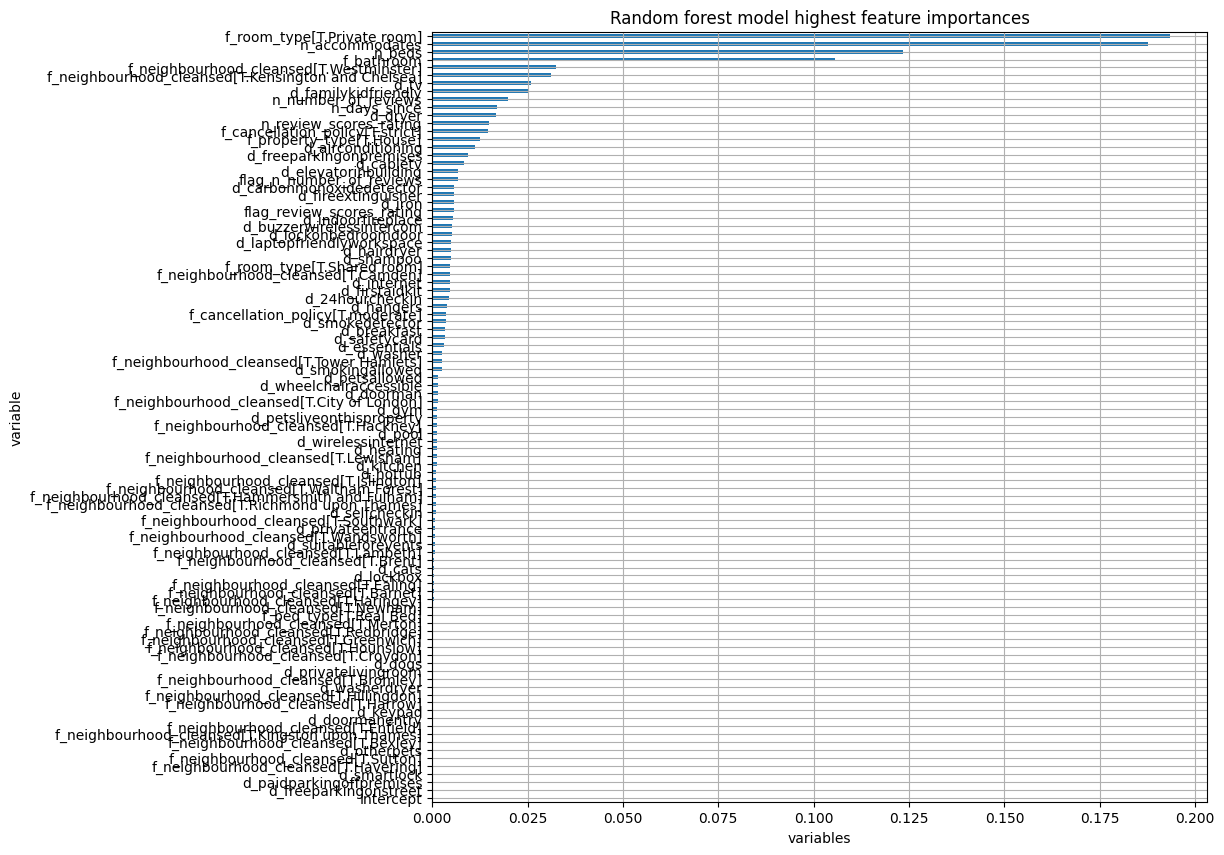

In [47]:
df_var_imp\
    .sort_values(by = 'imp')\
    .plot(kind = 'barh', 
          x = 'variable', y = 'imp', 
          figsize = (10,10), grid = True, 
          title = 'Random forest model highest feature importances', 
          xlabel = 'variables', legend = False
         );

In [48]:
# we only care for variables with an importance of more than 1 pct
cutoff = 0.01

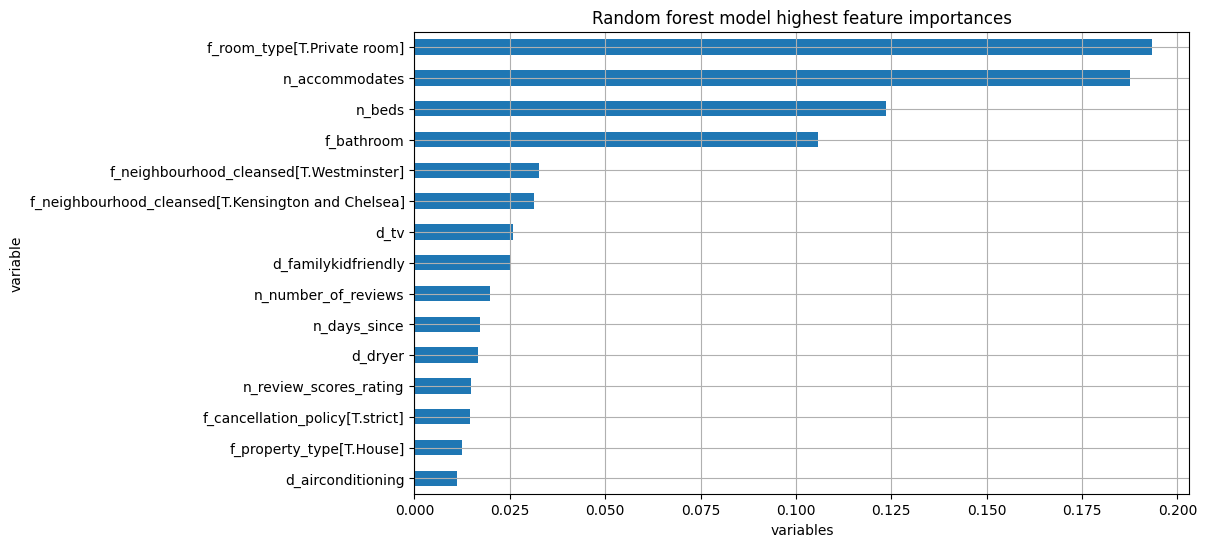

In [49]:
df_var_imp[df_var_imp.imp > cutoff]\
    .sort_values(by = 'imp')\
    .plot(kind = 'barh', 
          x = 'variable', y = 'imp', 
          figsize = (10,6), grid = True, 
          title = 'Random forest model highest feature importances', 
          xlabel = 'variables', legend = False
         );

Formatting x-axis lables as percentages.

In [50]:
import matplotlib.ticker as mtick

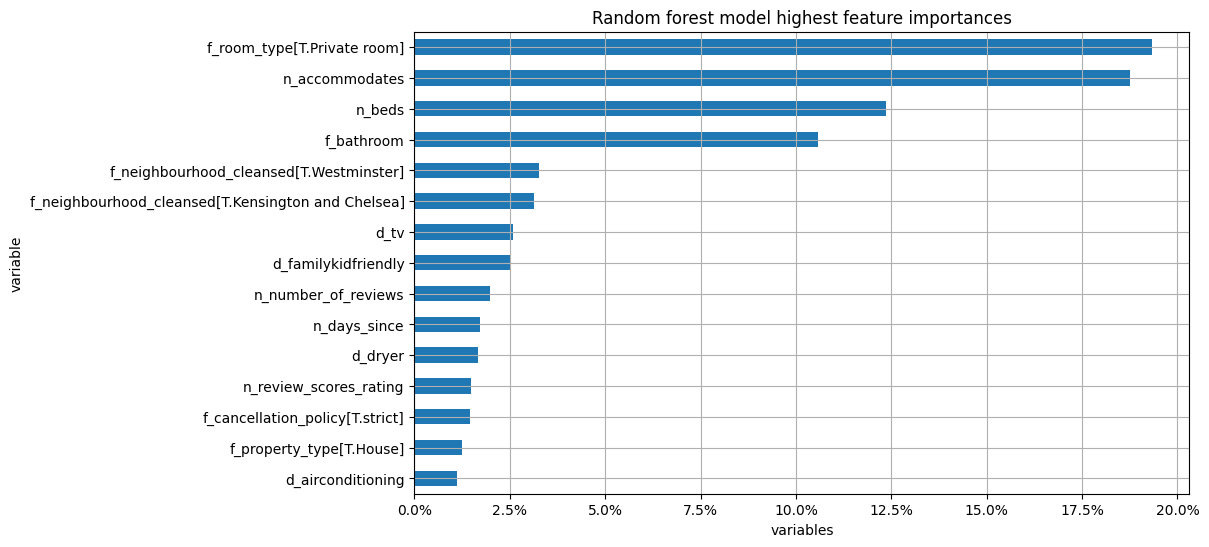

In [51]:
ax = df_var_imp[df_var_imp.imp > cutoff]\
    .sort_values(by = 'imp')\
    .plot(kind = 'barh',
          x = 'variable', 
          y = 'imp',
          figsize = (10,6), 
          grid = True,
          title = 'Random forest model highest feature importances',
          xlabel = 'variables', 
          legend = False)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

***Grouped variable importance - keep binaries created off factors together***

For this, you need to create an `sklearn` Pipeline including `OneHotEncoding` (before, encoding was done by patsy's `dmatrices`). This way permutation_importance can calculate factor variables' importance 

In [52]:
categorical_columns = [col for col in predictors_2 if col.startswith("f_")]
numerical_columns = [col for col in predictors_2 if col not in categorical_columns]

In [53]:
numerical_columns

['n_accommodates',
 'n_beds',
 'n_days_since',
 'n_number_of_reviews',
 'flag_n_number_of_reviews',
 'n_review_scores_rating',
 'flag_review_scores_rating',
 'd_24hourcheckin',
 'd_airconditioning',
 'd_breakfast',
 'd_buzzerwirelessintercom',
 'd_cabletv',
 'd_carbonmonoxidedetector',
 'd_cats',
 'd_dogs',
 'd_doorman',
 'd_doormanentry',
 'd_dryer',
 'd_elevatorinbuilding',
 'd_essentials',
 'd_familykidfriendly',
 'd_fireextinguisher',
 'd_firstaidkit',
 'd_freeparkingonpremises',
 'd_freeparkingonstreet',
 'd_gym',
 'd_hairdryer',
 'd_hangers',
 'd_heating',
 'd_hottub',
 'd_indoorfireplace',
 'd_internet',
 'd_iron',
 'd_keypad',
 'd_kitchen',
 'd_laptopfriendlyworkspace',
 'd_lockonbedroomdoor',
 'd_lockbox',
 'd_otherpets',
 'd_paidparkingoffpremises',
 'd_petsallowed',
 'd_petsliveonthisproperty',
 'd_pool',
 'd_privateentrance',
 'd_privatelivingroom',
 'd_safetycard',
 'd_selfcheckin',
 'd_shampoo',
 'd_smartlock',
 'd_smokedetector',
 'd_smokingallowed',
 'd_suitableforevent

In [54]:
categorical_columns

['f_property_type',
 'f_room_type',
 'f_bathroom',
 'f_cancellation_policy',
 'f_bed_type',
 'f_neighbourhood_cleansed']

In [55]:
categorical_encoder = OneHotEncoder(handle_unknown="ignore")

preprocessing = ColumnTransformer(
    [("cat", categorical_encoder, categorical_columns),
    ("num", "passthrough", numerical_columns)])

rf_pipeline = Pipeline(
    [("preprocess", preprocessing), 
     ("regressor", rf_model.best_estimator_)] # put best model to pipeline
)

In [56]:
%%time
rf_pipeline.fit(df_train[predictors_2],df_train.price)

CPU times: user 5.6 s, sys: 60.7 ms, total: 5.67 s
Wall time: 5.77 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

`Permutation feature importance` overcomes limitations of the impurity-based feature importance: **they do not have a bias toward high-cardinality features** and can be computed on a left-out test set.

In [57]:
%%time
result = permutation_importance(
    rf_pipeline,
    df_holdout[predictors_2],
    df_holdout.price,
    n_repeats=10,
    random_state=45,
)

CPU times: user 3min 7s, sys: 0 ns, total: 3min 7s
Wall time: 3min 7s


In [58]:
result

{'importances_mean': array([ 9.35648504e-02,  3.49913526e-02,  1.90534875e-03,  6.87591472e-03,
         2.73161744e-01,  1.00154226e-01,  1.64324558e-02,  8.97305117e-05,
         6.90195533e-02,  7.05717833e-03,  2.97301397e-03,  3.36139450e-03,
         4.21802556e-03,  1.19601781e-03,  7.23944014e-03,  4.79647496e-04,
         8.92490914e-04,  3.12180589e-03,  1.81152607e-03, -3.83480692e-05,
         2.81261089e-05,  2.60295562e-04, -7.95459031e-06,  7.14500242e-03,
         2.92202551e-03,  1.11417337e-03,  3.52969088e-03,  2.22604480e-03,
         8.39573053e-04,  5.95446474e-03,  9.07345332e-10,  2.75574366e-04,
         1.60844522e-03,  1.92001350e-03,  2.53420201e-04,  9.84150199e-05,
         1.88242989e-03,  5.49474303e-04,  1.90587149e-03,  1.71803406e-06,
         4.23506250e-04,  2.25063378e-03,  1.19944789e-03,  1.28037160e-04,
        -5.94306393e-07,  0.00000000e+00,  2.17546359e-04,  9.63600919e-05,
         5.84363972e-04,  2.40771527e-04, -6.73121874e-07,  1.013807

In [59]:
pd.DataFrame(
        result.importances_mean,
        df_train[predictors_2].columns)

,0
n_accommodates,0.093565
n_beds,0.034991
n_days_since,0.001905
f_property_type,0.006876
f_room_type,0.273162
...,...
d_tv,0.009542
d_washer,0.001492
d_washerdryer,0.000045
d_wheelchairaccessible,0.000211


In [60]:
grouped = [
    "f_bed_type",
    "f_property_type",
    "f_room_type",
    "f_bathroom",
    "n_days_since",
    "n_accommodates",
    "n_beds",
    "f_neighbourhood_cleansed",
    "f_cancellation_policy",
]

In [61]:
df_grouped_var_imp = pd.DataFrame(
        result.importances_mean,
        df_train[predictors_2].columns)\
    .loc[grouped]\
    .sort_values(by = 0, ascending = False)\
    .reset_index()\
    .rename({'index': 'variable', 0: 'imp'}, axis = 1)
df_grouped_var_imp['cumulative_imp'] = df_grouped_var_imp.imp.cumsum()

In [62]:
df_grouped_var_imp.style.format({
    'imp': lambda x: f'{x:,.1%}',
    'cumulative_imp': lambda x: f'{x:,.1%}'})

,variable,imp,cumulative_imp
0,f_room_type,27.3%,27.3%
1,f_bathroom,10.0%,37.3%
2,n_accommodates,9.4%,46.7%
3,f_neighbourhood_cleansed,6.9%,53.6%
4,n_beds,3.5%,57.1%
5,f_cancellation_policy,1.6%,58.7%
6,f_property_type,0.7%,59.4%
7,n_days_since,0.2%,59.6%
8,f_bed_type,0.0%,59.6%


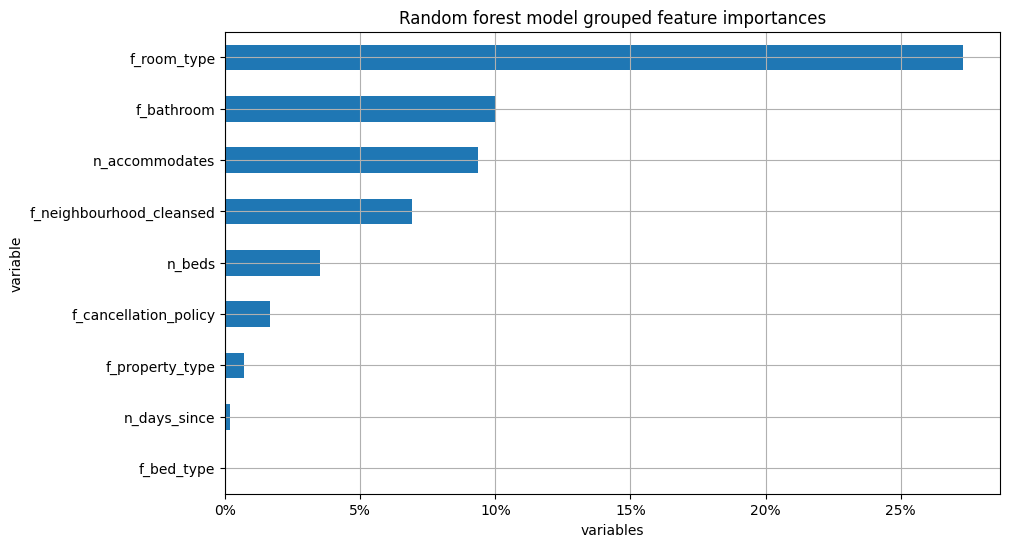

In [63]:
ax = df_grouped_var_imp\
    .sort_values(by = 'imp')\
    .plot(kind = 'barh', 
          x = 'variable', y = 'imp', 
          figsize = (10,6), grid = True, 
          title = 'Random forest model grouped feature importances', 
          xlabel = 'variables', legend = False
         )
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals = 0));

In [64]:
df_clean_varimp = pd.DataFrame(
        result.importances_mean,
        df_train[predictors_2].columns)\
    .sort_values(by = 0, ascending = False)\
    .reset_index()\
    .rename({'index': 'variable', 0: 'imp'}, axis = 1)

df_clean_varimp['cumulative_imp'] = df_var_imp['imp'].cumsum()
df_clean_varimp[df_clean_varimp.cumulative_imp < 0.91]

,variable,imp,cumulative_imp
0,f_room_type,0.273162,0.193466
1,f_bathroom,0.100154,0.381034
2,n_accommodates,0.093565,0.504563
3,f_neighbourhood_cleansed,0.069020,0.610238
4,n_beds,0.034991,0.642797
5,f_cancellation_policy,0.016432,0.674027
6,d_tv,0.009542,0.699864
7,d_airconditioning,0.007239,0.725226
8,d_dryer,0.007145,0.745128
9,n_number_of_reviews,0.007057,0.762233


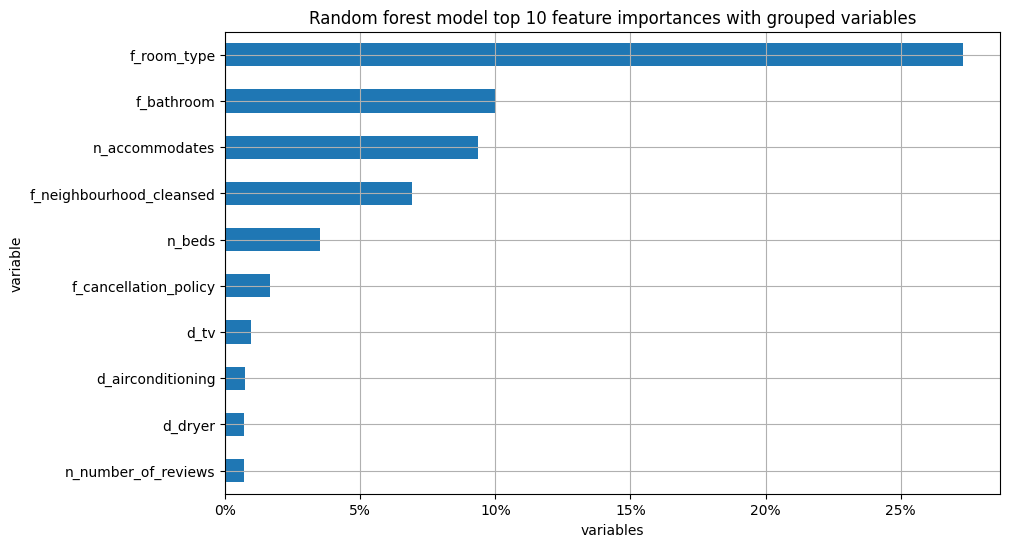

In [65]:
ax = df_clean_varimp.iloc[0:10]\
    .sort_values(by = 'imp')\
    .plot(kind = 'barh', 
          x = 'variable', y = 'imp', 
          figsize = (10,6), grid = True, 
          title = 'Random forest model top 10 feature importances with grouped variables', 
          xlabel = 'variables', legend = False
         )
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals = 0));

### Partial dependence plots 

Note: easy way, sklearn has plot_partial_dependence function we do this on holdout set!   
Also, note that we run it not on the `rf_model` but on the `rf_pipeline` to manage OneHot_Encoding on the fly.

In [66]:
accomodates_pdp = partial_dependence(
    rf_pipeline, df_holdout[predictors_2], ["n_accommodates"], kind="average"
)

In [67]:
accomodates_pdp

{'grid_values': [array([1, 2, 3, 4, 5, 6, 7])],
 'average': array([[ 76.56867001,  81.06567   ,  84.56486963,  96.20751284,
         104.59342806, 112.0837593 , 113.76153847]])}

In [68]:
# We need to access the elements of this complex data structure
type(accomodates_pdp)

sklearn.utils._bunch.Bunch

In [69]:
pd.DataFrame(
    {'number of accomodates': accomodates_pdp['grid_values'][0], 
     'average price': accomodates_pdp['average'][0]}
    )

,number of accomodates,average price
0,1,76.568670
1,2,81.065670
2,3,84.564870
3,4,96.207513
4,5,104.593428
5,6,112.083759
6,7,113.761538


We can do our pdp plots using Pandas built-in plot method.

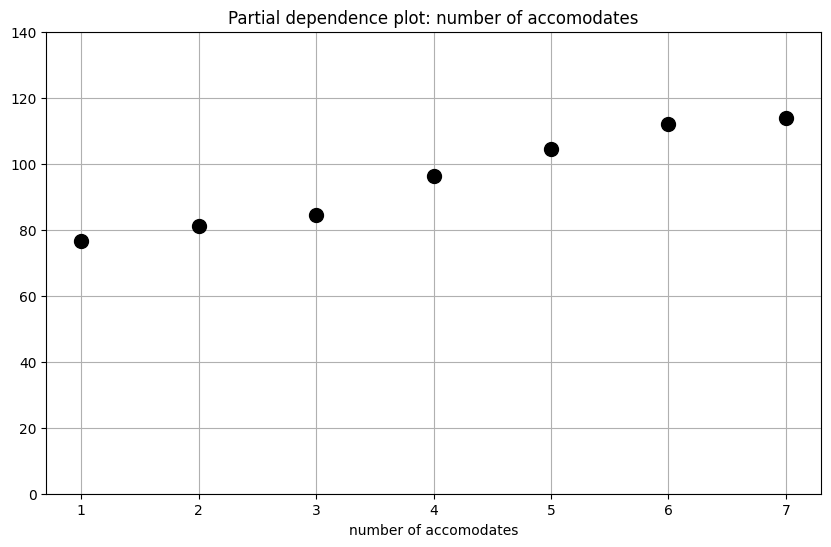

In [70]:
pd.DataFrame(
    {'number of accomodates': accomodates_pdp['grid_values'][0], 
     'average price': accomodates_pdp['average'][0]}
    ).sort_values(by = 'average price').plot(
    kind = 'line', color = 'k', marker = 'o', markersize = 10, linewidth = 0,
    figsize = (10,6), legend = False, grid = True,
    x = 'number of accomodates', y = 'average price', ylim = (0, 140), 
    title = 'Partial dependence plot: number of accomodates'
);

`sklearn` has its own visualization with complicated syntax. 

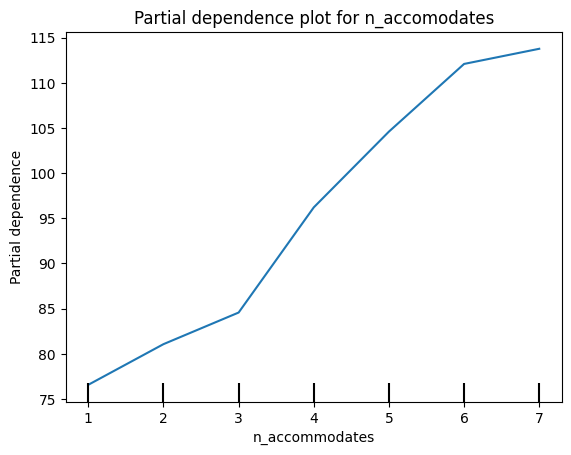

In [71]:
display = PartialDependenceDisplay(
    pd_results = [accomodates_pdp],
    features = [(0,)], 
    feature_names = df_holdout[predictors_2].columns.tolist(), 
    target_idx = 0,
    deciles = {0: np.linspace(1, 7, num=7)}
)
display.plot()
plt.title('Partial dependence plot for n_accomodates')
plt.show();

In [72]:
roomtype_pdp = partial_dependence(
    rf_pipeline, df_holdout[predictors_2], ["f_room_type"], kind="average"
)

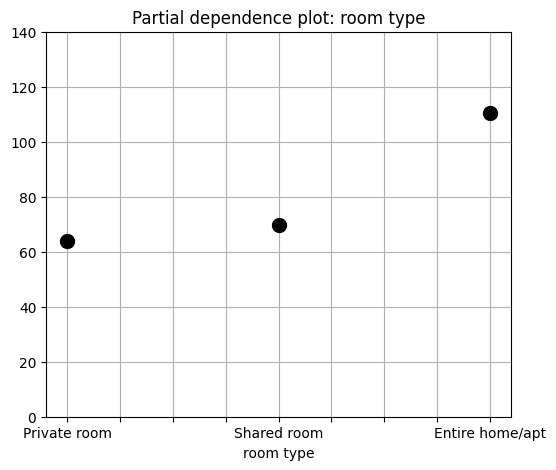

In [73]:
pd.DataFrame(
    {'room type': roomtype_pdp['grid_values'][0], 
     'average price': roomtype_pdp['average'][0]}
    ).sort_values(by = 'average price').plot(
    kind = 'line', color = 'k', marker = 'o', markersize = 10, linewidth = 0,
    figsize = (6,5), legend = False, grid = True,
    x = 'room type', y = 'average price', ylim = (0, 140), 
    title = 'Partial dependence plot: room type'
);

#### Subsample performance: RMSE / mean(y) 

NOTE:  we do this on the holdout set, using the encoding pipeline `rf_pipeline` again.


In [74]:
df_holdout_w_prediction = df_holdout.assign(
    predicted_price=rf_pipeline.predict(df_holdout[predictors_2])
)

KeyboardInterrupt: 

***Creating tables of heterogeneity by various grouping factors***
- apartman size

This is how we start:

In [ ]:
df_holdout_w_prediction['is_low_size'] = df_holdout_w_prediction.n_accommodates.map(lambda x: 'small apt' if x < 3 else 'large apt')

In [ ]:
df_holdout_w_prediction.iloc[0:5, -5:]

In [ ]:
df_holdout_w_prediction.groupby('is_low_size').apply(lambda x: mean_squared_error(x.predicted_price, x.price, squared=False))

Putting it in a function with additional columns

In [ ]:
def calculate_rmse(groupby_obj):
    return (
        groupby_obj.apply(
            lambda x: mean_squared_error(x.predicted_price, x.price, squared=False),
        )
        .to_frame(name="rmse")
        .assign(mean_price=groupby_obj.apply(lambda x: np.mean(x.price)).values)
        .assign(rmse_normalized=lambda x: x.rmse / x.mean_price).round(2)
    )

In [ ]:
# cheaper or more expensive flats - not used in book
grouped_object = df_holdout_w_prediction.assign(
    is_low_size=lambda x: np.where(x.n_accommodates <= 3, "small apt", "large apt")
).groupby("is_low_size")
accom_subset = calculate_rmse(grouped_object)

In [ ]:
accom_subset

- fancy neighborhoods

In [ ]:
grouped_object = df_holdout_w_prediction.loc[
    lambda x: x.f_neighbourhood_cleansed.isin(
        [
            "Westminster",
            "Camden",
            "Kensington and Chelsea",
            "Tower Hamlets",
            "Hackney",
            "Newham",
        ]
    )
].groupby("f_neighbourhood_cleansed")
neightbourhood_subset = calculate_rmse(grouped_object)

neightbourhood_subset.sort_values(by = 'mean_price', ascending = False).style.format({'rmse': '{:.1f}', 'mean_price': '{:.1f}', 'rmse_normalized': '{:.2f}'})

- property type

In [ ]:
grouped_object = df_holdout_w_prediction.loc[
    lambda x: x.f_property_type.isin(["Apartment", "House"])
].groupby("f_property_type")
proptype_subset = calculate_rmse(grouped_object)

proptype_subset.style.format({'rmse': '{:.1f}', 'mean_price': '{:.1f}', 'rmse_normalized': '{:.2f}'})

In [ ]:
all_holdout = pd.DataFrame(
    [
        mean_squared_error(
            df_holdout_w_prediction.price,
            df_holdout_w_prediction.predicted_price,
            squared=False,
        ),
        df_holdout_w_prediction.price.mean(),
    ],
    index=["rmse", "mean_price"],
).T.assign(rmse_normalized=lambda x: x.rmse / x.mean_price).round(2)
all_holdout.index = ["Total"]

all_holdout.style.format({'rmse': '{:.1f}', 'mean_price': '{:.1f}', 'rmse_normalized': '{:.2f}'})

In [ ]:
type_rows = pd.DataFrame(
    None,
    index=["Apartment size", "Type", "Borough", "------"],
    columns=["rmse", "mean_price", "rmse_normalized"],
).fillna("------")

In [ ]:
type_rows

**Finally: subsample performance**

In [ ]:
pd.concat(
    [
        type_rows.iloc[[0]],
        accom_subset,
        type_rows.iloc[[1]],
        proptype_subset,
        type_rows.iloc[[2]],
        neightbourhood_subset,
        type_rows.iloc[[3]],
        all_holdout,
    ]
)

### Horserace: compare with other models 


1. ***OLS with dummies for area***

 using model B

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
y, X = dmatrices("price ~ " + " + ".join(predictors_2), df_train)

ols_model = LinearRegression().fit(X,y)

#y_test, X_test = dmatrices("price ~ " + " + ".join(predictors_2), df_holdout)

y_hat = ols_model.predict(X)

ols_rmse = mean_squared_error(y,y_hat,squared=False)
ols_rmse

In [ ]:
ols_model_coeffs_df = pd.DataFrame(
    ols_model.coef_.tolist()[0],
    index=X.design_info.column_names,
    columns=["ols_coefficient"],
).assign(ols_coefficient=lambda x: x.ols_coefficient.round(3))

In [ ]:
ols_model_coeffs_df

2.  LASSO

using extended model w interactions

In [ ]:
from sklearn.linear_model import ElasticNet

The `ElasticNet` model is combines L1 (LASSO) and L2 (Ridge) in a single class. 

The parameter `l1_ratio` (between [0,1]) is the weight of LASSO and Ridge. l1_ratio = 1 is the pure lasso penalty. Currently, l1_ratio <= 0.01 is not reliable, unless you supply your own sequence of alpha.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html

In [ ]:
lasso_model =  ElasticNet(l1_ratio = 1, fit_intercept = True)

In [ ]:
lasso_model_cv = GridSearchCV(
    lasso_model,
    # {"alpha":[i/100 for i in range(1, 26, 1)]}, #> this option takes forever to run
    {"alpha":[i/100 for i in range(5, 26, 5)]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=3,
)


In [ ]:
y, X = dmatrices("price ~ " + " + ".join(predictors_E), df_train)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
%%time
lasso_model_cv.fit(X_scaled, y.ravel())

In [ ]:
lasso_model_cv.best_estimator_

In [ ]:
lasso_rmse = pd.DataFrame(lasso_model_cv.cv_results_).loc[
    lambda x: x.param_alpha == lasso_model_cv.best_estimator_.alpha
].mean_test_score.values[0] * -1
lasso_rmse

3. ***CART model***

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
y, X = dmatrices("price ~ " + " + ".join(predictors_2), df_train)

In [ ]:
X.shape

In [ ]:
cart_model = DecisionTreeRegressor(random_state=20250224)

Get potential ccp_alpha parameters

In [ ]:
path = cart_model.cost_complexity_pruning_path(X, y.ravel())
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Minimal cost-complexity pruning is an algorithm used to prune a tree to avoid over-fitting. This algorithm is parameterized by 
 known as the complexity parameter. The complexity parameter is used to define the cost-complexity measure.

<center>
 $R_a(T) = R(T) + \alpha(\hat{T})$   
</center>
 
 where $R(T)$ is the cost-complexity measure, and $\alpha(\hat{T})$ is the number of terminal nodes of tree $T$. 

 By defalut `DecisionTreeRegressor` uses `squared error` as criterion for goodness-of-fit.

In [ ]:
ccp_alphas

In [ ]:
ccp_alphas.shape

In [ ]:
impurities

Apply random search to select a "best" alpha, default is 10 iterations
`RandomizedSearchCV` does not calculate all potential alphas, just a random 10-element subset of the many potential alphas

In [ ]:
%%time

cart_model_cv = RandomizedSearchCV(
    cart_model,
    {"ccp_alpha":ccp_alphas},
    cv = 5,
    scoring="neg_root_mean_squared_error",
    verbose = 3,
)
cart_model_cv.fit(X,y.ravel())

In [ ]:
cart_model_cv.best_estimator_

In [ ]:
cart_rmse = pd.DataFrame(cart_model_cv.cv_results_).loc[
    lambda x: x.param_ccp_alpha == cart_model_cv.best_estimator_.ccp_alpha
].mean_test_score.values[0] * -1
cart_rmse

4. GBM

**NOTE:** With complex grid search run for a **very long time**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gbm = GradientBoostingRegressor(learning_rate=0.1, min_samples_split=20, max_features = 10
                                #, n_estimators = 50
                               )

tune_grid = {"n_estimators": [200, 300], "max_depth": [5, 10]}

gbm_model_cv = GridSearchCV(
    gbm,
    tune_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=10,
    n_jobs=-1
)

In [ ]:
categorical_columns = [col for col in predictors_2 if col.startswith("f_")]
numerical_columns = [col for col in predictors_2 if col not in categorical_columns]

categorical_encoder = OneHotEncoder(handle_unknown="ignore")

preprocessing = ColumnTransformer(
    [
        ("cat", categorical_encoder, categorical_columns),
        ("num", "passthrough", numerical_columns),
    ]
)

gbm_pipe = Pipeline(
    [("preprocess", preprocessing), ("regressor", gbm_model_cv)], verbose=True
)

In [ ]:
%%time
gbm_pipe.fit(df_train[predictors_2],df_train.price)

In [ ]:
gbm_model_cv.best_estimator_

In [ ]:
gbm_rmse = gbm_model_cv.best_score_*-1

In [ ]:
gbm_rmse

Comparing model results on CV RMSE.

In [ ]:
pd.DataFrame({'model': ['OLS', 'LASSO', 'CART', 'random forest', 'GBM'],
              'CV RMSE': [ols_rmse, lasso_rmse, cart_rmse, all_holdout.rmse[0], gbm_rmse]})

***Histogram-based Gradient Boosting Regression Tree***

Histogram-based Gradient Boosting Regression Tree. It is experimental so we need to enable experimental features first. This implementation is inspired by [LightGBM](https://github.com/Microsoft/LightGBM).

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
hgbm_broad = HistGradientBoostingRegressor(random_state = 20250224)

In [ ]:
"""
tune_grid = {
    "max_iter": [50, 100, 200],
    "max_depth": [1, 5, 10],
    "learning_rate": [0.1, 0.15, 0.2],
    "min_samples_leaf": [5, 10, 20, 30],
}
"""
# for the sake of simplicity we run on only a restricted tuning set on class
tune_grid = {
    # "max_iter": [50, 100, 200],
    "max_iter": [200],
    # "max_depth": [1, 5, 10],
    "max_depth": [5, 10],
    # "learning_rate": [0.1, 0.15, 0.2],
    "learning_rate": [0.1, 0.15],
    "min_samples_leaf": [10, 20],
}

hgbm_model_cv_broad = GridSearchCV(
    hgbm_broad,
    tune_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=10,
)

In [ ]:
categorical_columns = [col for col in predictors_2 if col.startswith("f_")]
numerical_columns = [col for col in predictors_2 if col not in categorical_columns]

categorical_encoder = OneHotEncoder(handle_unknown="ignore")

preprocessing = ColumnTransformer(
    [
        ("cat", categorical_encoder, categorical_columns),
        ("num", "passthrough", numerical_columns),
    ]
)

hgbm_pipe_broad = Pipeline(
    [("preprocess", preprocessing), ("regressor", hgbm_model_cv_broad)], verbose=True
)

In [ ]:
%%time
hgbm_pipe_broad.fit(df_train[predictors_2],df_train.price)

In [ ]:
hgbm_model_cv_broad.best_params_

In [ ]:
print('Broad HGBM RMSE is: {:.4f}.'.format(hgbm_model_cv_broad.best_score_*-1))
print('Simple GBM RMSE is: {:.4f}.'.format(gbm_model_cv.best_score_*-1))